# Mushroom Classification Project
Predict whether a mushroom is edible or poisonous using machine learning.

## Define Project

https://www.kaggle.com/datasets/uciml/mushroom-classification

## Challenge?

The challenge in this project is to build a machine learning model that can accurately classify mushrooms as either edible or poisonous based on their physical characteristics. This is a classification problem where the goal is to correctly identify harmful mushrooms to help prevent accidental poisoning.

## 1. Import Libraries

In [21]:
import pandas as pd # pandas is used for handling data tables
import numpy as np
import matplotlib.pyplot as plt # matplotlib is used for plotting graphs

## 2. Load Data

In [22]:
df = pd.read_csv("mushrooms.csv") # i loaded the dataset from the csv file
df.head ()# shows the first few rows of the dataset

#This dataset contains different physical features of mushrooms, like color, smell, shape, and texture. 
#We use these features to train a model that predicts whether a mushroom is safe to eat or poisonous.

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


## 3. Initial Exploration

In [23]:
print("Shape:", df.shape) # print number of rows and columns
df.info() # shows info about each column (data types, nulls, etc.)

#The dataset contains 8,124 mushroom samples and 23 features (columns) in total. 
#Each row represents one mushroom, and each column describes a specific physical characteristic
#such as cap shape, odor, gill color, and habitat.

Shape: (8124, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-

## 4. Check Missing Values

In [24]:
df.isnull().sum() # checked if there are any missing values in each column

#This output shows that the dataset has no missing values at all.
# we are checking each column to see if any data is missing (null or empty values). 
#The result shows 0 for every column, which means, every mushroom sample has complete information

class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

## 5. Handle '?' Values

In [25]:
# in this dataset, "?" acts like a missing value
# replace it with the word "missing" so it becomes a valid category
df["stalk-root"] = df["stalk-root"].replace("?", "missing")

## 6. Encode Target Variable

In [26]:
# convert target labels into numbers
# edible = 0, poisonous = 1
df["class"] = df["class"].map({"e": 0, "p": 1})

## 7. Class Distribution

In [27]:
# i checked how many edible vs poisonous mushrooms there are
df["class"].value_counts()

#We checked how many mushrooms are edible versus poisonous. The dataset is quite balanced, with about 4208 edible mushrooms and 3916 poisonous ones. 
#This balance helps the model learn both classes more fairly and improves prediction accuracy

class
0    4208
1    3916
Name: count, dtype: int64

## 8. Feature Visualization

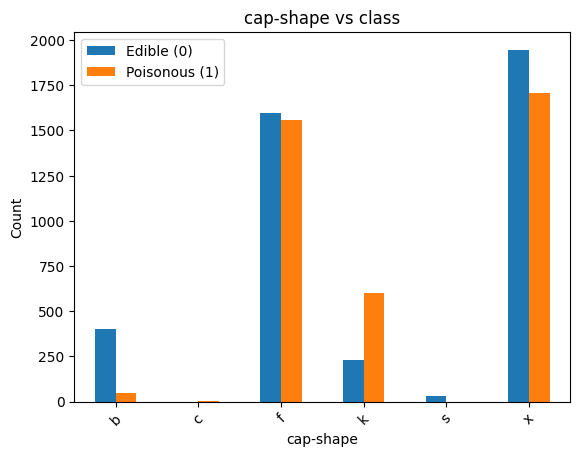

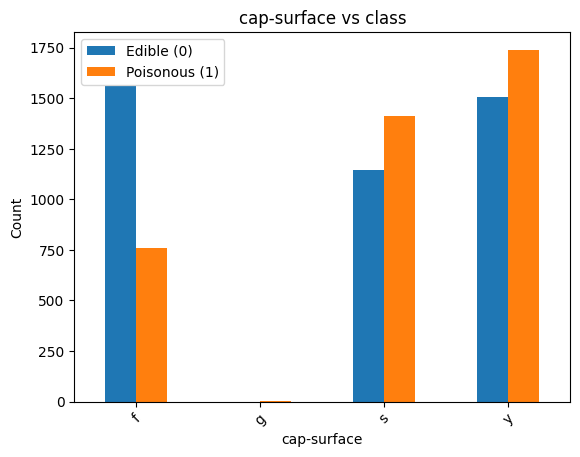

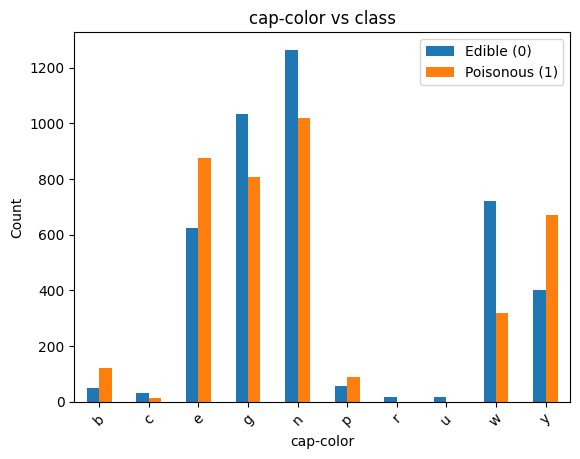

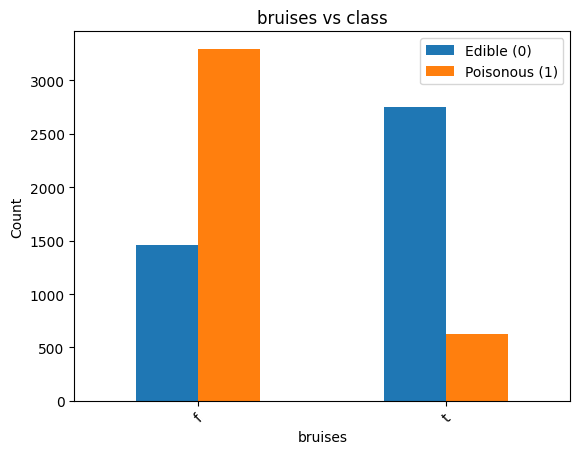

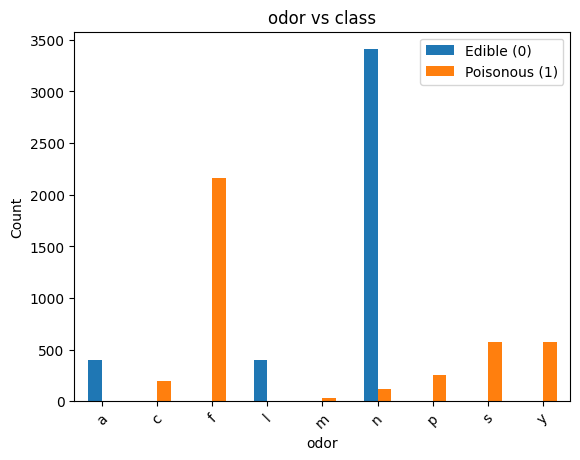

In [28]:
# loop through a few features to visualize
for col in df.columns[1:6]:
    
    # I created a table of counts for each category vs class
    ct = pd.crosstab(df[col], df["class"])
    
    # plot bar graph
    ct.plot(kind="bar")
    
    # add labels and title
    plt.title(f"{col} vs class")
    plt.xlabel(col)
    plt.ylabel("Count")
    
    # rotate labels so they are readable
    plt.xticks(rotation=45)
    
    # legend
    plt.legend(["Edible (0)", "Poisonous (1)"])
    
    plt.show()

This code helps us understand how different mushroom features are related to whether they are edible or poisonous. For each feature, we count how many mushrooms fall into each category and separate them by class. Then we visualize it using bar graphs so we can clearly see patterns-like whether certain odors or shapes are more common in poisonous mushrooms.”

## 9. One-Hot Encoding

In [29]:
df_encoded = pd.get_dummies(df)

It converts all categorical (text-based) columns in your dataset into numerical format 

## 10. Train/Test Split

In [30]:
from sklearn.model_selection import train_test_split

# separate features (X) and target (y)
X = df_encoded.drop("class", axis=1)
y = df_encoded["class"]

# split into training (70%) and temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

# split temp into validation (15%) and test (15%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

I split the data into training, validation, and test sets. The model learns from the training data, gets tuned using the validation set, and is finally evaluated on the test set to see how well it performs on new data. This helps ensure it learns patterns instead of memorizing

## 11. Train Logistic Regression

In [31]:
# import logistic regression model and accuracy metric
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# create the model
# using logistic regression as a simple baseline model
model = LogisticRegression(max_iter=1000)

# train the model on training data
# the model learns relationships between features and the class
model.fit(X_train, y_train)

# make predictions on validation data (data the model has not seen)
preds = model.predict(X_val)

# calculate how accurate the predictions are
acc = accuracy_score(y_val, preds)

# print the result
print("logistic regression acc:", acc)

logistic regression acc: 1.0


I used Logistic Regression as a baseline model. It was trained on the training data and then tested on validation data it hadn’t seen before. I used accuracy to measure how well it predicted whether mushrooms are edible or poisonous. The Logistic Regression model achieved an accuracy of 1.0 on the validation set, meaning it correctly classified every sample it was tested on.

## 12. Evaluate Model

In [34]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_val)
print("Validation Accuracy:", accuracy_score(y_val, y_pred))

Validation Accuracy: 1.0


Here I used the trained Logistic Regression model to make predictions on the validation dataset and then compared those predictions to the actual labels using accuracy. The validation accuracy is 1.0, which means the model correctly classified 100% of the validation mushrooms as either edible or poisonous.

## 13. Try Decision Tree

In [35]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier()
tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_val)
print("Decision Tree Accuracy:", accuracy_score(y_val, y_pred_tree))

Decision Tree Accuracy: 1.0


Here I trained a Decision Tree model, which is another machine learning algorithm used for classification. It works by splitting the data into branches based on feature values to make predictions. The Decision Tree model also achieved 100% accuracy on the validation data, meaning it correctly classified all mushrooms as edible or poisonous with no errors.